# Gram Type Classification

We will build one single envelope trained on true-label score vectors:

- For a gram-neg phage: use its scores as-is (low score = strong evidence against gram postive thus gram-neg signal is good)
- For a gram-pos phage: use 1 − score for every dimension (the original scores measure gram-positive evidence)

Every training phage contributes exactly one point to the envelope — its score vector oriented toward its true host. The envelope learns what a true infector looks like, regardless of which gram type that is.

### At Testing
For each test phage we will create two candidate score vectors:
1. Scores as-is → hypothesis: this phage is gram-neg
2. 1 − scores  → hypothesis: this phage is gram-pos

We check both against the single envelope:
- Both inside  → prediction set = {gram-neg, gram-pos} (size 2, uncertain)
- Only as-is inside → prediction set = {gram-neg} (size 1)
- Only flipped inside → prediction set = {gram-pos} (size 1)
- Neither inside → prediction set = {} (size 0)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time
import pickle
import warnings
warnings.filterwarnings('ignore')

### Loading the Data

In [2]:
SCORES_PATH = "../../Data/host_type_all_preds.csv"
METADATA_PATH = "../../Data/metadata.csv"
SPLITS_PATH = "../../Data/all_random_pc_splits.pkl"

print("Loading scores...")
t0 = time.time()
scores_df = pd.read_csv(SCORES_PATH, index_col="proteinID")
print(f"  scores shape : {scores_df.shape}  ({time.time()-t0:.1f}s)")

print("Loading metadata...")
t0 = time.time()
meta_df = pd.read_csv(METADATA_PATH, index_col="proteinID")
print(f"  metadata shape : {meta_df.shape}  ({time.time()-t0:.1f}s)")

meta_df = meta_df[["accession", "host_type", "split"]]

print("Loading protein-level functional cross-validation splits...")
t0 = time.time()
with open(SPLITS_PATH, "rb") as f:
    pc_splits = pickle.load(f)
print(f"  splits matrix loaded ({time.time()-t0:.1f}s)")

Loading scores...
  scores shape : (1853074, 40)  (3.0s)
Loading metadata...
  metadata shape : (1853074, 8)  (3.4s)
Loading protein-level functional cross-validation splits...
  splits matrix loaded (4.8s)


#### Seeing how the data looks like

In [3]:
# scores file
print(scores_df.head())

                host_type_lysin  host_type_endolysin  host_type_val  \
proteinID                                                             
AB002632_00001              NaN                  NaN            NaN   
AB002632_00002              NaN                  NaN            NaN   
AB002632_00003              NaN                  NaN            NaN   
AB002632_00004              NaN                  NaN            NaN   
AB002632_00005              NaN                  NaN            NaN   

                host_type_capsid  host_type_baseplate  \
proteinID                                               
AB002632_00001               NaN                  NaN   
AB002632_00002               NaN                  NaN   
AB002632_00003          0.029791                  NaN   
AB002632_00004               NaN                  NaN   
AB002632_00005          0.008570                  NaN   

                host_type_tail_appendage  host_type_tail_sheath  \
proteinID                          

In [4]:
# metadata file
print(meta_df.head(10))

               accession host_type  split
proteinID                                
AB002632_00001  AB002632  gram-neg      0
AB002632_00002  AB002632  gram-neg      0
AB002632_00003  AB002632  gram-neg      0
AB002632_00004  AB002632  gram-neg      0
AB002632_00005  AB002632  gram-neg      0
AB002632_00006  AB002632  gram-neg      0
AB002632_00007  AB002632  gram-neg      0
AB002632_00008  AB002632  gram-neg      0
AB002632_00009  AB002632  gram-neg      0
AB002632_00010  AB002632  gram-neg      0


### Joining and Mean-Pooling to Phage Level
We apply the leakage fix at the protein level BEFORE aggregation. If a protein fell within the training cluster set for a given function model, its value is masked out to NaN so that the mean pooling step handles it properly as missing data.

In [5]:
score_cols = [c for c in scores_df.columns if c.startswith("host_type_")]

print("Applying protein-level cross-validation masking...")
t0 = time.time()
scores_masked = scores_df.copy()

for col in score_cols:
    func = col.replace("host_type_", "")   # e.g. "lysin", "capsid"
    # Find ALL splits columns for this function, across all hosts
    matching_split_cols = [c for c in pc_splits.columns if c.endswith("_" + func)]
    
    if len(matching_split_cols) == 0:
        print(f"  WARNING: no splits columns found for function '{func}' — skipping")
        continue
    
    # A protein is clean only if it was in split 0 for ALL host models using this function
    is_test = (pc_splits[matching_split_cols] == 0).all(axis=1)
    scores_masked[col] = scores_df[col].where(is_test)

print(f"  Done in {time.time()-t0:.1f}s")

Applying protein-level cross-validation masking...
  Done in 104.8s


### Train / Test Split + Median Imputation
We impute all the NaNs with the median value of the column

In [6]:
combined = scores_masked.join(meta_df, how="inner")
score_cols = [c for c in scores_masked.columns if c.startswith("host_type_")]

t0 = time.time()
phage_scores = combined.groupby("accession")[score_cols].mean()
phage_meta = combined.groupby("accession")[["host_type", "split"]].first()
phage_df = phage_scores.join(phage_meta)

print(f"Phage-level shape: {phage_df.shape}  ({time.time()-t0:.1f}s)")
print("\nGram-type distribution:")
print(phage_df["host_type"].value_counts())
print("\nSplit distribution:")
print(phage_df["split"].value_counts().sort_index())

# Isolating the structural metadata groups directly to fix data leakage / homology-bias:
train_all_folds_df = phage_df[phage_df["split"] != 0].copy()
test_df = phage_df[phage_df["split"] == 0].copy()

train_all_folds_df = train_all_folds_df[train_all_folds_df["host_type"].isin(["gram-neg", "gram-pos"])]
test_df = test_df[test_df["host_type"].isin(["gram-neg", "gram-pos"])]

print(f"Total Available Training Phages (Folds 1-4): {len(train_all_folds_df)}")
print(f"Test phages (Split 0) : {len(test_df)}")

Phage-level shape: (18474, 42)  (0.5s)

Gram-type distribution:
host_type
gram-neg    10735
gram-pos     7708
unknown        31
Name: count, dtype: int64

Split distribution:
split
0    4433
1    3173
2    3646
3    3588
4    3634
Name: count, dtype: int64
Total Available Training Phages (Folds 1-4): 14021
Test phages (Split 0) : 4422


### NaN Column Filtering
No column dropping — use all score columns

In [7]:
valid_cols = score_cols
K = len(valid_cols)
print(f"Using all columns: K = {K}")

Using all columns: K = 40


#### Median imputation (from training set only)

In [8]:
train_medians = train_all_folds_df[valid_cols].median()
safe_impute_values = train_medians.copy()
safe_impute_values[safe_impute_values > 0.6] = 0.5

train_all_folds_df[valid_cols] = train_all_folds_df[valid_cols].fillna(safe_impute_values)
test_df[valid_cols] = test_df[valid_cols].fillna(safe_impute_values)
train_all_folds_df[valid_cols] = train_all_folds_df[valid_cols].fillna(0.5)
test_df[valid_cols] = test_df[valid_cols].fillna(0.5)

print(f"\nResidual NaNs — train: {train_all_folds_df[valid_cols].isna().sum().sum()}")
print(f"Residual NaNs — test : {test_df[valid_cols].isna().sum().sum()}")


Residual NaNs — train: 0
Residual NaNs — test : 0


#### Checking the data characteristics

In [9]:
print("Mean score per gram type (averaged across all K columns):")
for gt in ["gram-neg", "gram-pos"]:
    mask = train_all_folds_df["host_type"] == gt
    mean_score = train_all_folds_df.loc[mask, valid_cols].mean().mean()
    median_score = train_all_folds_df.loc[mask, valid_cols].median().median()
    print(f"  {gt}: mean={mean_score:.4f}, median={median_score:.4f}, n={mask.sum()}")

print("\nPer-column mean scores (gram-neg vs gram-pos):")
col_means = pd.DataFrame({
    "gram-neg": train_all_folds_df[train_all_folds_df["host_type"]=="gram-neg"][valid_cols].mean(),
    "gram-pos": train_all_folds_df[train_all_folds_df["host_type"]=="gram-pos"][valid_cols].mean(),
})

col_means["gram-neg > gram-pos"] = col_means["gram-neg"] > col_means["gram-pos"]

print(col_means.to_string())
print(f"\nColumns where gram-neg scores higher: {col_means['gram-neg > gram-pos'].sum()} / {len(valid_cols)}")

test_raw = test_df[valid_cols].values
test_labels = test_df["host_type"].values

Mean score per gram type (averaged across all K columns):
  gram-neg: mean=0.4651, median=0.5000, n=7924
  gram-pos: mean=0.4651, median=0.5000, n=6097

Per-column mean scores (gram-neg vs gram-pos):
                                     gram-neg  gram-pos  gram-neg > gram-pos
host_type_lysin                      0.500000  0.500000                False
host_type_endolysin                  0.500000  0.500000                False
host_type_val                        0.500000  0.500000                False
host_type_capsid                     0.500000  0.500000                False
host_type_baseplate                  0.500000  0.500158                False
host_type_tail_appendage             0.500000  0.500076                False
host_type_tail_sheath                0.500000  0.500000                False
host_type_portal                     0.500000  0.500000                False
host_type_head-tail_joining          0.500000  0.500000                False
host_type_integration         

### Envelope Methods

In [10]:
def split_data_by_fold(df, valid_cols, test_fold_id):
    """
    Splits the data based on non-overlapping metadata folds to ensure 
    that the training/calibration split remains fully unbiased.
    """
    s1_df = df[df["split"] != test_fold_id]
    s2_df = df[df["split"] == test_fold_id]
    
    labels_s2 = s2_df["host_type"].values
    
    # Process S1 matrix
    s1_raw = s1_df[valid_cols].values
    s1_labels = s1_df["host_type"].values
    S1_nc = np.zeros_like(s1_raw)
    S1_nc[s1_labels == "gram-neg"] = s1_raw[s1_labels == "gram-neg"]
    S1_nc[s1_labels == "gram-pos"] = 1.0 - s1_raw[s1_labels == "gram-pos"]
    
    # Process S2 matrix
    s2_raw = s2_df[valid_cols].values
    S2_nc = np.zeros_like(s2_raw)
    S2_nc[labels_s2 == "gram-neg"] = s2_raw[labels_s2 == "gram-neg"]
    S2_nc[labels_s2 == "gram-pos"] = 1.0 - s2_raw[labels_s2 == "gram-pos"]
    
    return S1_nc, S2_nc, labels_s2

In [11]:
def quantile_for_class(tau_scores, labels, cls, alpha):
    mask = labels == cls
    vals = np.sort(tau_scores[mask])
    n = len(vals)
    idx = int(np.ceil((n + 1) * (1 - alpha))) - 1
    return vals[np.clip(idx, 0, n - 1)]

#### Radial Method

In [12]:
def sample_positive_sphere(M, K):
    V = np.abs(np.random.randn(M, K))
    return V / (np.linalg.norm(V, axis=1, keepdims=True) + 1e-12)

def radial_build_envelope_unbiased(df, valid_cols, fold_id, alpha, M=200, delta_deg=30):
    S1, S2, labels_S2 = split_data_by_fold(df, valid_cols, fold_id)
    K = S1.shape[1]
    U = sample_positive_sphere(M, K)
    mags = np.linalg.norm(S1, axis=1)
    dirs = S1 / (mags[:, None] + 1e-12)
    cos_thresh = np.cos(np.radians(delta_deg))
    q_tilde = np.zeros(M)
    for m in range(M):
        mask = (dirs @ U[m]) >= cos_thresh
        q_tilde[m] = np.quantile(mags[mask], 1 - alpha) if mask.sum() > 5 else np.quantile(mags, 1 - alpha)
    boundary = U * q_tilde[:, None]
    tau_scores = (S2[:, None, :] / (boundary[None, :, :] + 1e-12)).max(axis=2).min(axis=1)
    
    t_hat = max(quantile_for_class(tau_scores, labels_S2, "gram-neg", alpha),
                quantile_for_class(tau_scores, labels_S2, "gram-pos", alpha))
    return {"U": U, "q_tilde": q_tilde, "t_hat": t_hat, "method": "radial"}

def radial_is_in_region(scores, envelope):
    U, q_tilde, t_hat = envelope["U"], envelope["q_tilde"], envelope["t_hat"]
    boundary = U * (q_tilde * t_hat)[:, None]
    return np.any(np.all(scores[:, None, :] <= boundary[None, :, :], axis=2), axis=1)

#### Strip Method

In [13]:
def strip_shape_discovery(S1, alpha, M):
    N1, K = S1.shape
    bin_edges = np.zeros((K, M + 1))
    for j in range(K):
        bin_edges[j] = np.linspace(S1[:, j].min(), S1[:, j].max(), M + 1)
    limits = np.zeros((K, K, M))
    for j in range(K):
        for m in range(M):
            lo, hi = bin_edges[j, m], bin_edges[j, m + 1]
            in_strip = (S1[:, j] >= lo) & (S1[:, j] < hi)
            for i in range(K):
                if i == j: continue
                if in_strip.sum() < 3:
                    limits[j, i, m] = np.quantile(S1[:, i], 1 - alpha)
                else:
                    limits[j, i, m] = np.quantile(S1[in_strip, i], 1 - alpha)
    for j in range(K):
        for i in range(K):
            if i == j: continue
            for m in range(M - 2, -1, -1):
                limits[j, i, m] = max(limits[j, i, m], limits[j, i, m + 1])
    return bin_edges, limits


def get_bin_indices(scores, bin_edges):
    """For each point and dimension, find which bin it falls in."""
    N, K = scores.shape
    M = bin_edges.shape[1] - 1
    indices = np.zeros((N, K), dtype=int)
    for j in range(K):
        raw = np.digitize(scores[:, j], bin_edges[j]) - 1
        indices[:, j] = np.clip(raw, 0, M - 1)
    return indices

def strip_size_scaling(S2, bin_edges, limits, alpha):
    N2, K = S2.shape
    bin_idx = get_bin_indices(S2, bin_edges)
    ratios = np.zeros((N2, K, K))
    for j in range(K):
        for i in range(K):
            if i == j: continue
            lims = limits[j, i, bin_idx[:, j]]
            ratios[:, j, i] = S2[:, i] / (lims + 1e-12)
    return ratios.max(axis=(1, 2))


def strip_is_in_region(scores, envelope):
    bin_edges, limits, t_hat = envelope["bin_edges"], envelope["limits"], envelope["t_hat"]
    N, K = scores.shape
    bin_idx = get_bin_indices(scores, bin_edges)
    scaled_limits = limits * t_hat
    inside = np.ones(N, dtype=bool)
    for j in range(K):
        for i in range(K):
            if i == j: continue
            inside &= (scores[:, i] <= scaled_limits[j, i, bin_idx[:, j]])
    return inside

def strip_build_envelope_unbiased(df, valid_cols, fold_id, alpha, M=20):
    S1, S2, labels_S2 = split_data_by_fold(df, valid_cols, fold_id)
    bin_edges, limits = strip_shape_discovery(S1, alpha, M)

    tau_neg = strip_size_scaling(S2[labels_S2 == "gram-neg"], bin_edges, limits, alpha)
    tau_pos = strip_size_scaling(S2[labels_S2 == "gram-pos"], bin_edges, limits, alpha)
    t_hat = max(quantile_for_class(tau_neg, np.full(len(tau_neg), "gram-neg"), "gram-neg", alpha),
                quantile_for_class(tau_pos, np.full(len(tau_pos), "gram-pos"), "gram-pos", alpha))
    return {"bin_edges": bin_edges, "limits": limits, "t_hat": t_hat, "method": "strip"}


#### Collapsed 1D Method

In [14]:
def collapsed_build_envelope_unbiased(df, valid_cols, fold_id, alpha):
    S1, S2, labels_S2 = split_data_by_fold(df, valid_cols, fold_id)
    
    S1_1d = S1.mean(axis=1, keepdims=True)
    S2_1d = S2.mean(axis=1, keepdims=True)
    
    q_tilde = np.quantile(S1_1d, 1 - alpha)
    tau_scores = (S2_1d / (q_tilde + 1e-12)).ravel()

    t_hat = max(quantile_for_class(tau_scores, labels_S2, "gram-neg", alpha),
                quantile_for_class(tau_scores, labels_S2, "gram-pos", alpha))

    return {"q_tilde": q_tilde, "t_hat": t_hat, "method": "collapsed"}

def collapsed_is_in_region(scores_1d, envelope):
    threshold = envelope["q_tilde"] * envelope["t_hat"]
    return (scores_1d.ravel() <= threshold)

#### Function to check if the point is in the envelope

In [15]:
def is_in_region(scores, envelope):
    if envelope["method"] == "radial":
        return radial_is_in_region(scores, envelope)
    elif envelope["method"] == "strip":
        return strip_is_in_region(scores, envelope)
    else:
        return collapsed_is_in_region(scores, envelope)

### Prediction

In [16]:
def predict_gram_type_nc(test_raw, envelope):
    nc_gramneg = test_raw           # (N_test, K) — gram-neg NC
    nc_grampos = 1.0 - test_raw     # (N_test, K) — gram-pos NC

    if envelope["method"] == "collapsed":
        nc_gramneg = nc_gramneg.mean(axis=1, keepdims=True)
        nc_grampos = nc_grampos.mean(axis=1, keepdims=True)

    in_gramneg = is_in_region(nc_gramneg, envelope)   # (N_test,) bool
    in_grampos = is_in_region(nc_grampos, envelope)   # (N_test,) bool

    results = []
    for i in range(len(test_raw)):
        pred_set = []
        if in_gramneg[i]: pred_set.append("gram-neg")
        if in_grampos[i]: pred_set.append("gram-pos")
        results.append({
            "in_gramneg" : bool(in_gramneg[i]),
            "in_grampos" : bool(in_grampos[i]),
            "prediction_set" : pred_set
        })
    return results

#### Building the Envelope

In [17]:
# np.random.seed(42)
# alpha = 0.1

# print("Building radial envelope on NC scores...")
# t0 = time.time()
# radial_env = radial_build_envelope(train_nc, alpha, M=200, delta_deg=30, labels=train_labels)
# print(f"  Done in {time.time()-t0:.1f}s  |  t_hat = {radial_env['t_hat']:.4f}")

# print("\nBuilding strip envelope on NC scores...")
# t0  = time.time()
# strip_env = strip_build_envelope(train_nc, alpha, M=20, labels=train_labels)
# print(f"  Done in {time.time()-t0:.1f}s  |  t_hat = {strip_env['t_hat']:.4f}")

# print("\nBuilding collapsed 1D envelope on NC scores...")
# t0  = time.time()
# collapsed_env = collapsed_build_envelope(train_nc_1d, alpha, labels=train_labels)
# print(f"  Done in {time.time()-t0:.1f}s  |  threshold = {collapsed_env['q_tilde'] * collapsed_env['t_hat']:.4f}")

### Evaluation
Testing on test data

In [18]:
def evaluate(results, true_labels, method_name, alpha, verbose=True):
    n = len(results)
    set_sizes = [len(r["prediction_set"]) for r in results]
    covered = sum(true_labels[i] in r["prediction_set"] for i, r in enumerate(results))
    singletons = [(r, true_labels[i]) for i, r in enumerate(results) if len(r["prediction_set"]) == 1]
    correct_singletons = sum(r["prediction_set"][0] == lbl for r, lbl in singletons)
    empty = sum(s == 0 for s in set_sizes)
    size2 = sum(s == 2 for s in set_sizes)

    if verbose: print(f"\n{'='*58}")
    if verbose: print(f" {method_name.upper()} — {n} test phages | alpha={alpha}")
    if verbose: print(f"\n{'='*58}")
    if verbose: print(f" Coverage : {covered/n:.3f}  (target >= {1-alpha:.2f})")
    return {
        "coverage" : covered / n,
        "avg_set_size" : np.mean(set_sizes),
        "empty_rate" : empty / n,
        "singleton_rate" : len(singletons) / n,
        "size2_rate" : size2 / n,
        "singleton_accuracy" : correct_singletons / len(singletons) if singletons else None,
        "set_sizes" : set_sizes,
        "per_type_coverage"  : {
            gt: sum(true_labels[i] in results[i]["prediction_set"]
                    for i in [j for j, lbl in enumerate(true_labels) if lbl == gt])
               / max(1, sum(lbl == gt for lbl in true_labels))
            for gt in ["gram-neg", "gram-pos"]
        },
    }

In [19]:
# Running iterations across the explicit available cross-validation loops
available_folds = [1, 2, 3, 4]
all_metrics = {"radial": [], "strip": [], "collapsed": []}
alpha = 0.1

print(f"Executing evaluations tracking explicit metadata divisions across folds: {available_folds}")
for run, fold_id in enumerate(available_folds):
    r_env = radial_build_envelope_unbiased(train_all_folds_df, valid_cols, fold_id, alpha, M=200, delta_deg=30)
    s_env = strip_build_envelope_unbiased (train_all_folds_df, valid_cols, fold_id, alpha, M=20)
    c_env = collapsed_build_envelope_unbiased(train_all_folds_df, valid_cols, fold_id, alpha)

    r_res = predict_gram_type_nc(test_raw, r_env)
    s_res = predict_gram_type_nc(test_raw, s_env)
    c_res = predict_gram_type_nc(test_raw, c_env)

    for key, results in [("radial", r_res), ("strip", s_res), ("collapsed", c_res)]:
        all_metrics[key].append(evaluate(results, test_labels, key, alpha, verbose=False))
    print(f"  Metadata Split Group {fold_id} complete.")

Executing evaluations tracking explicit metadata divisions across folds: [1, 2, 3, 4]


  Metadata Split Group 1 complete.
  Metadata Split Group 2 complete.
  Metadata Split Group 3 complete.
  Metadata Split Group 4 complete.


In [20]:
# Store final loop calculations for comparative rendering
radial_results    = r_res
strip_results     = s_res
collapsed_results = c_res

methods_names = ["Radial", "Strip", "Collapsed 1D"]
method_keys   = ["radial", "strip", "collapsed"]

print(f"\n{'='*65}")
print(f" SUMMARY ACROSS FOLDS 1-4 (alpha={alpha})")
print(f"{'='*65}")
for name, key in zip(methods_names, method_keys):
    runs = all_metrics[key]
    cov = np.array([m["coverage"] for m in runs])
    cov_neg = np.array([m["per_type_coverage"]['gram-neg'] for m in runs])
    cov_pos = np.array([m["per_type_coverage"]['gram-pos'] for m in runs])
    avg_size = np.array([m["avg_set_size"] for m in runs])
    sing_acc = np.array([m["singleton_accuracy"] for m in runs if m["singleton_accuracy"] is not None])
    print(f"\n  {name}")
    print(f"    Overall coverage : {cov.mean():.3f} ± {cov.std():.3f}  (target >= {1-alpha:.2f})")
    print(f"    gram-neg coverage: {cov_neg.mean():.3f} ± {cov_neg.std():.3f}")
    print(f"    gram-pos coverage: {cov_pos.mean():.3f} ± {cov_pos.std():.3f}")
    print(f"    Avg set size     : {avg_size.mean():.3f} ± {avg_size.std():.3f}")
    if len(sing_acc):
        print(f"    Singleton acc.   : {sing_acc.mean():.3f} ± {sing_acc.std():.3f}")


 SUMMARY ACROSS FOLDS 1-4 (alpha=0.1)

  Radial
    Overall coverage : 0.477 ± 0.275  (target >= 0.90)
    gram-neg coverage: 0.750 ± 0.433
    gram-pos coverage: 0.000 ± 0.001
    Avg set size     : 0.750 ± 0.433
    Singleton acc.   : 0.636 ± 0.000

  Strip
    Overall coverage : 0.000 ± 0.000  (target >= 0.90)
    gram-neg coverage: 0.000 ± 0.000
    gram-pos coverage: 0.000 ± 0.000
    Avg set size     : 0.000 ± 0.000

  Collapsed 1D
    Overall coverage : 0.637 ± 0.000  (target >= 0.90)
    gram-neg coverage: 1.000 ± 0.000
    gram-pos coverage: 0.003 ± 0.000
    Avg set size     : 1.001 ± 0.000
    Singleton acc.   : 0.636 ± 0.000


In [21]:
rows = []
for name, key in zip(methods_names, method_keys):
    runs = all_metrics[key]
    cov = np.array([m["coverage"] for m in runs])
    cov_neg = np.array([m["per_type_coverage"]['gram-neg'] for m in runs])
    cov_pos = np.array([m["per_type_coverage"]['gram-pos'] for m in runs])
    avg_size = np.array([m["avg_set_size"] for m in runs])
    empty = np.array([m["empty_rate"] for m in runs])
    size2 = np.array([m["size2_rate"] for m in runs])
    sing_acc = np.array([m["singleton_accuracy"] for m in runs if m["singleton_accuracy"] is not None])
    rows.append({
        "Method" : name,
        "Coverage" : f"{cov.mean():.3f}±{cov.std():.3f}",
        "Neg coverage" : f"{cov_neg.mean():.3f}±{cov_neg.std():.3f}",
        "Pos coverage" : f"{cov_pos.mean():.3f}±{cov_pos.std():.3f}",
        "Avg set size" : f"{avg_size.mean():.3f}±{avg_size.std():.3f}",
        "Empty %" : f"{empty.mean()*100:.1f}±{empty.std()*100:.1f}",
        "Size-2 %" : f"{size2.mean()*100:.1f}±{size2.std()*100:.1f}",
        "Singleton acc.": f"{sing_acc.mean():.3f}±{sing_acc.std():.3f}" if len(sing_acc) else "N/A",
    })
summary = pd.DataFrame(rows)
print("\nFinal Comparative Performance Summary DataFrame:")
print(summary.to_string())


Final Comparative Performance Summary DataFrame:
         Method     Coverage Neg coverage Pos coverage Avg set size    Empty % Size-2 % Singleton acc.
0        Radial  0.477±0.275  0.750±0.433  0.000±0.001  0.750±0.433  25.0±43.3  0.0±0.0    0.636±0.000
1         Strip  0.000±0.000  0.000±0.000  0.000±0.000  0.000±0.000  100.0±0.0  0.0±0.0            N/A
2  Collapsed 1D  0.637±0.000  1.000±0.000  0.003±0.000  1.001±0.000    0.0±0.0  0.1±0.0    0.636±0.000


### Comparison Plots

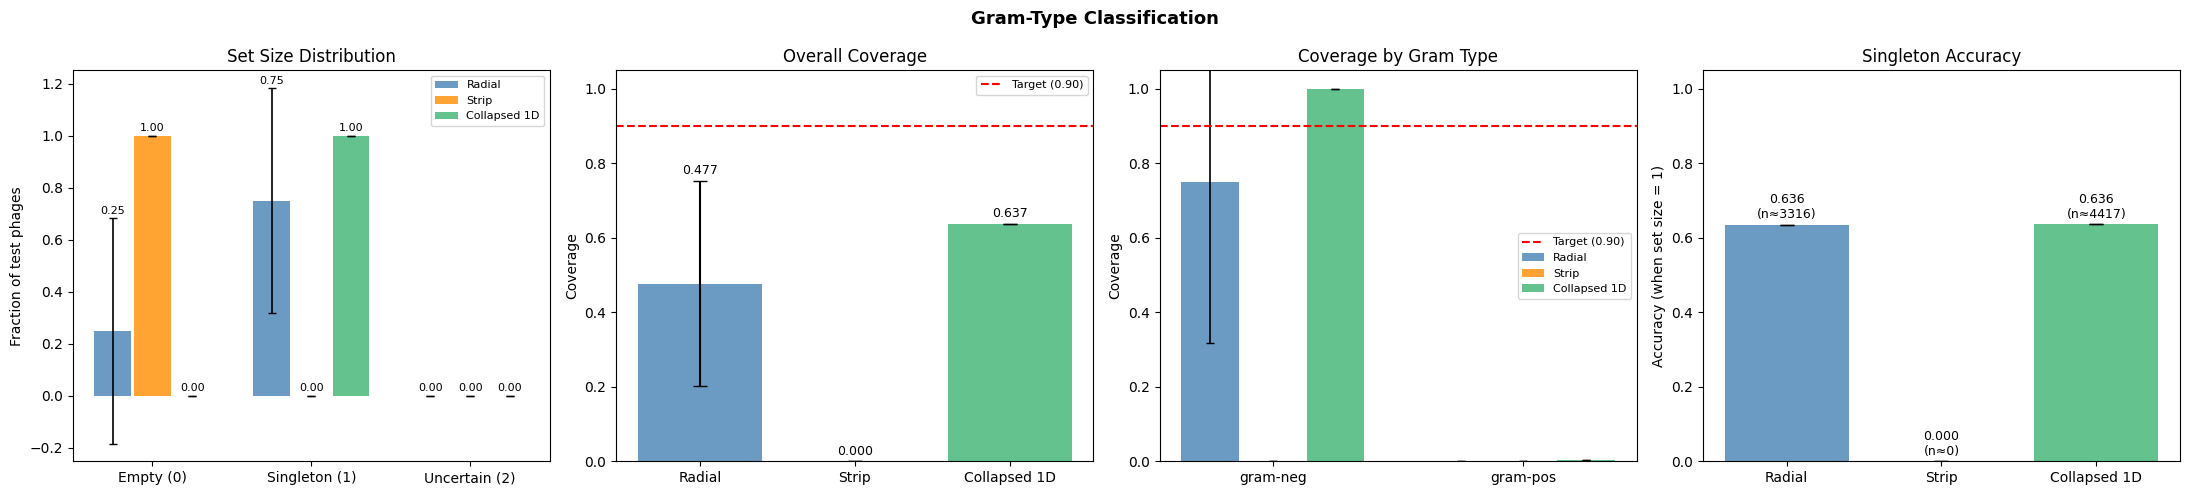

In [22]:
fig, axes = plt.subplots(1, 4, figsize=(22, 5))
colors = ["steelblue", "darkorange", "mediumseagreen"]

def _mean_std(key, field):
    vals = np.array([m[field] for m in all_metrics[key]])
    return vals.mean(), vals.std()

# Plot 1: Set size distribution (fraction of phages) 
ax = axes[0]
x = np.array([0, 1, 2])
offsets = [-0.25, 0.0, 0.25]
for name, key, c, offset in zip(methods_names, method_keys, colors, offsets):
    means, stds = [], []
    for s in [0, 1, 2]:
        fracs = np.array([
            sum(1 for sz in m["set_sizes"] if sz == s) / len(m["set_sizes"])
            for m in all_metrics[key]
        ])
        means.append(fracs.mean())
        stds.append(fracs.std())
    bars = ax.bar(x + offset, means, width=0.23, label=name, color=c, alpha=0.8)
    ax.errorbar(x + offset, means, yerr=stds, fmt="none", color="black", capsize=3, linewidth=1.2)
    for rect in bars:
        height = rect.get_height()
        ax.text(rect.get_x() + rect.get_width()/2, means[list(bars).index(rect)] + stds[list(bars).index(rect)] + 0.01, 
                f'{height:.2f}', ha='center', va='bottom', fontsize=8)
ax.set_xticks(x)
ax.set_xticklabels(["Empty (0)", "Singleton (1)", "Uncertain (2)"])
ax.set_title("Set Size Distribution")
ax.set_ylabel("Fraction of test phages")
ax.legend(fontsize=8)

# Plot 2: Overall coverage 
ax = axes[1]
means = [np.mean([m["coverage"] for m in all_metrics[k]]) for k in method_keys]
stds = [np.std ([m["coverage"] for m in all_metrics[k]]) for k in method_keys]
bars = ax.bar(methods_names, means, color=colors, alpha=0.8)
ax.errorbar(range(len(methods_names)), means, yerr=stds, fmt="none", color="black", capsize=5, linewidth=1.5)
ax.axhline(1 - alpha, color="red", linestyle="--", label=f"Target ({1-alpha:.2f})")
ax.set_ylim(0, 1.05)
ax.set_title("Overall Coverage")
ax.set_ylabel("Coverage")
ax.legend(fontsize=8)
for i, (bar, val, std) in enumerate(zip(bars, means, stds)):
    ax.text(bar.get_x() + bar.get_width()/2, val + std + 0.01, f"{val:.3f}", ha="center", va="bottom", fontsize=9)

# Plot 3: Per-gram-type coverage
ax = axes[2]
gram_types = ["gram-neg", "gram-pos"]
x = np.arange(len(gram_types))
offsets = [-0.25, 0.0, 0.25]
for name, key, c, offset in zip(methods_names, method_keys, colors, offsets):
    means, stds = [], []
    for gt in gram_types:
        vals = np.array([m["per_type_coverage"][gt] for m in all_metrics[key]])
        means.append(vals.mean())
        stds.append(vals.std())
    ax.bar(x + offset, means, width=0.23, label=name, color=c, alpha=0.8)
    ax.errorbar(x + offset, means, yerr=stds, fmt="none", color="black", capsize=3, linewidth=1.2)
ax.axhline(1 - alpha, color="red", linestyle="--", label=f"Target ({1-alpha:.2f})")
ax.set_xticks(x)
ax.set_xticklabels(gram_types)
ax.set_ylim(0, 1.05)
ax.set_title("Coverage by Gram Type")
ax.set_ylabel("Coverage")
ax.legend(fontsize=8)

# Plot 4: Singleton accuracy
ax = axes[3]
means, stds, ns = [], [], []
for key in method_keys:
    vals = np.array([m["singleton_accuracy"] for m in all_metrics[key] if m["singleton_accuracy"] is not None])
    means.append(vals.mean() if len(vals) else 0)
    stds.append (vals.std()  if len(vals) else 0)
    ns.append(int(np.mean([m["singleton_rate"] * len(m["set_sizes"]) for m in all_metrics[key]])))
bars = ax.bar(methods_names, means, color=colors, alpha=0.8)
ax.errorbar(range(len(methods_names)), means, yerr=stds, fmt="none", color="black", capsize=5, linewidth=1.5)
ax.set_ylim(0, 1.05)
ax.set_title("Singleton Accuracy")
ax.set_ylabel("Accuracy (when set size = 1)")
for bar, val, std, n_s in zip(bars, means, stds, ns):
    ax.text(bar.get_x() + bar.get_width()/2, val + std + 0.01, f"{val:.3f}\n(n≈{n_s})", ha="center", va="bottom", fontsize=9)

plt.suptitle(f"Gram-Type Classification", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

### Score distribution

In [23]:
def plot_nonconformity_space_2d(train_df, valid_cols):
    """
    Plots the first two available feature score channels to visualize 
    how the score-flipping handles origin alignment in nonconformity space.
    """
    if len(valid_cols) < 2:
        print("Insufficient dimensions to map a 2D coordinate plot.")
        return
        
    col1, col2 = valid_cols[0], valid_cols[1]
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
    colors = {"gram-neg": "royalblue", "gram-pos": "darkorange"}
    
    # 1. Plot Raw Vector Spaces
    for gt in ["gram-neg", "gram-pos"]:
        sub = train_df[train_df["host_type"] == gt]
        ax1.scatter(sub[col1], sub[col2], color=colors[gt], label=gt, alpha=0.5, edgecolors='none')
    ax1.set_xlabel(f"Raw {col1}")
    ax1.set_ylabel(f"Raw {col2}")
    ax1.set_title("Raw Model Probability Outputs")
    ax1.grid(True, linestyle='--', alpha=0.5)
    ax1.legend()
    
    # 2. Plot Flipped Nonconformity Space Transformations
    for gt in ["gram-neg", "gram-pos"]:
        sub = train_df[train_df["host_type"] == gt]
        x_vals = sub[col1] if gt == "gram-neg" else 1.0 - sub[col1]
        y_vals = sub[col2] if gt == "gram-neg" else 1.0 - sub[col2]
        ax2.scatter(x_vals, y_vals, color=colors[gt], label=gt, alpha=0.5, edgecolors='none')
        
    ax2.set_xlabel(f"NC Dimension 1 ({col1})")
    ax2.set_ylabel(f"NC Dimension 2 ({col2})")
    ax2.set_title("Transformed Nonconformity Space (Origin Clustered)")
    ax2.grid(True, linestyle='--', alpha=0.5)
    ax2.legend()
    
    plt.tight_layout()
    plt.show()


Generating 2D nonconformity coordinate trajectory chart...


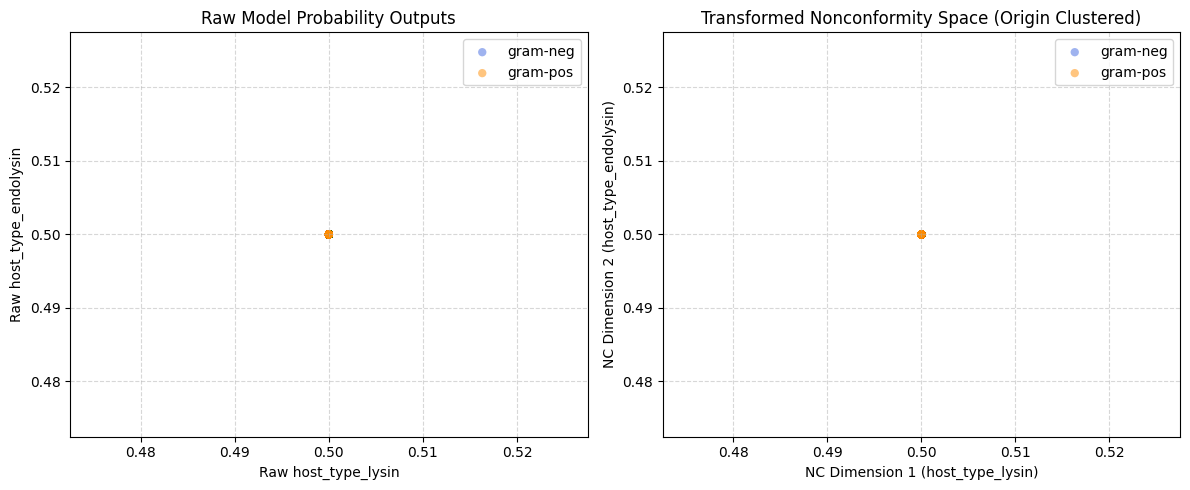

In [24]:
print("\nGenerating 2D nonconformity coordinate trajectory chart...")
plot_nonconformity_space_2d(train_all_folds_df, valid_cols)


Generating raw score distribution histogram...


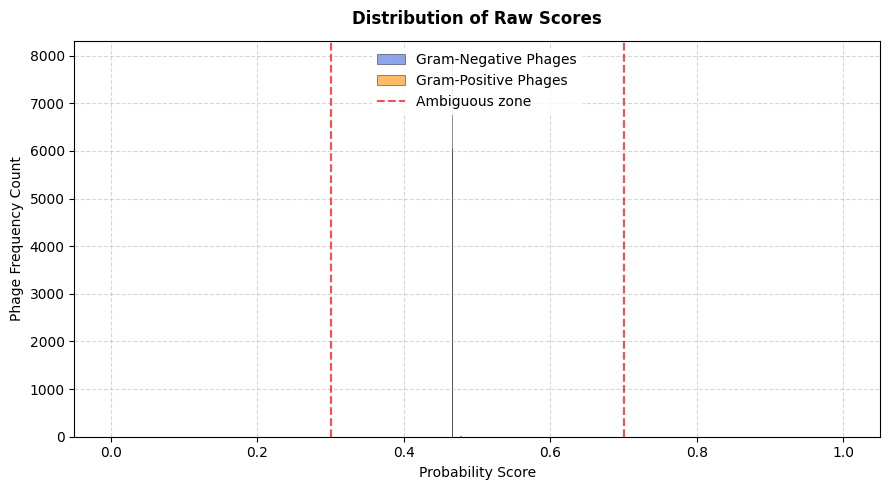

In [25]:
print("\nGenerating raw score distribution histogram...")

# Compute the mean prediction score per phage across all valid dimensions
train_neg_scores = train_all_folds_df[train_all_folds_df["host_type"] == "gram-neg"][valid_cols].mean(axis=1)
train_pos_scores = train_all_folds_df[train_all_folds_df["host_type"] == "gram-pos"][valid_cols].mean(axis=1)

plt.figure(figsize=(9, 5))

# Plot overlaying histograms with transparency (alpha) to observe class separation
plt.hist(train_neg_scores, bins=50, alpha=0.6, color='royalblue', label='Gram-Negative Phages', edgecolor='black', linewidth=0.5)
plt.hist(train_pos_scores, bins=50, alpha=0.6, color='darkorange', label='Gram-Positive Phages', edgecolor='black', linewidth=0.5)

# Add formal chart decorations for M2 thesis reporting
plt.title("Distribution of Raw Scores", fontsize=12, fontweight='bold', pad=12)
plt.xlabel("Probability Score", fontsize=10)
plt.ylabel("Phage Frequency Count", fontsize=10)
plt.axvline(0.3, color="red", linestyle="--", alpha=0.7, label="Ambiguous zone")
plt.axvline(0.7, color="red", linestyle="--", alpha=0.7)
plt.grid(True, linestyle='--', alpha=0.5)
plt.xlim(-0.05, 1.05)  # Align limits tightly across the probability spectrum [0, 1]
plt.legend(loc='upper center', frameon=True, facecolor='white', edgecolor='none')

plt.tight_layout()
plt.show()